In [ ]:
!pip install diffusers transformers accelerate safetensors opencv-python pillow torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu121


In [ ]:
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
import torch

# Charger ControlNet orienté "canny" pour des contours nets
controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-canny", torch_dtype=torch.float16
)

# Charger le modèle principal de Stable Diffusion
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    model_id, controlnet=controlnet, torch_dtype=torch.float16
).to("cuda")

pipe.enable_attention_slicing()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

...

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


  0%|          | 0/30 [00:00<?, ?it/s]

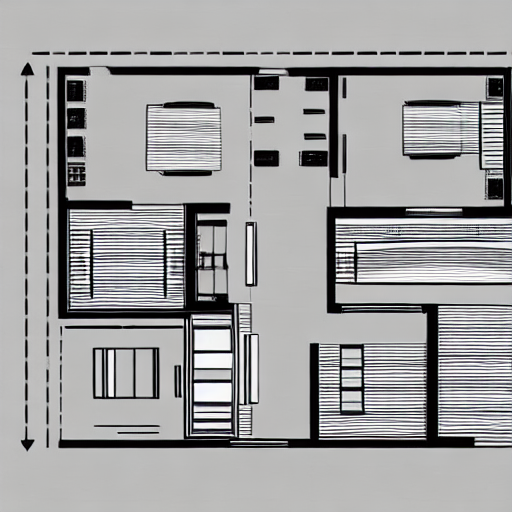

In [ ]:
from PIL import Image
import numpy as np
import cv2

# Pas besoin d'image d'entrée : on simule une base vide
base = np.zeros((512, 512, 3), dtype=np.uint8)

# On crée des "bords" canny pour aider ControlNet à structurer l'image
edges = cv2.Canny(base, 100, 200)
edges_image = Image.fromarray(edges)

prompt = (
    "architectural floor plan of a 3-bedroom modern house, minimalist, "
    "black and white, top view, professional architectural drawing"
)

image = pipe(prompt, image=edges_image, num_inference_steps=30, guidance_scale=9.0).images[0]
image.save("plan_autoarchitect.png")
image
